### Maximum dynamical ACA offset size between 2016:180 to 2017:180

Compute the maximum dynamical ACA offsets.

In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
from chandra_aca.drift import get_aca_offsets
from astropy.table import Table
import json
import numpy as np
from Chandra.Time import DateTime
from Ska.Matplotlib import plot_cxctime

In [3]:
zero_offsets = Table.read("""
date_effective cycle_effective detector   chipx   chipy chip_id obsvis_cal  color
2013-12-01     17               ACIS-I    930.2  1009.6    3      1.8a      black
2013-12-01     17               ACIS-S    200.7   476.9    7      1.8a      blue
2013-12-01     17               HRC-I    7591.0  7936.1    0      1.8a      green
2013-12-01     17               HRC-S    2041.0  9062.7    2      1.8a      Purple
2016-09-01     18               ACIS-I    970.0   975.0    3      1.9       red
2016-09-01     18               ACIS-S    210.0   520.0    7      1.9       orange
2016-09-01     18               HRC-I    7590.0  7745.0    0      1.9       cyan
2016-09-01     18               HRC-S    2195.0  8915.0    2      1.9       magenta
""", format='ascii')

In [4]:
latest_char = json.loads(open('/proj/sot/ska/data/aimpoint_mon/characteristics/CHARACTERIS_31JAN16.json').read())

In [5]:
r_max = 0
for zo in zero_offsets:
    for t_ccd in [-11.5]:
        for date in ['2016:314', '2017:180']:
            dy, dz = get_aca_offsets(zo['detector'], zo['chip_id'], zo['chipx'], zo['chipy'], 
                                     date, t_ccd)
            # subtract off the OFLS characteristics for the ACIS-I and ACIS-S
            if zo['detector'] == 'ACIS-I':
                dy -= latest_char['dy_acis_i']
                dz -= latest_char['dz_acis_i']
            if zo['detector'] == 'ACIS-S':
                dy -= latest_char['dy_acis_s']
                dz -= latest_char['dz_acis_s']
            r = np.hypot(dy, dz)
            if r > r_max:
                r_max = r
            print('t_ccd={:6.2f} degC cycle={} date={}, det={:6s} dy={:6.2f} dz={:6.2f} '
                  'r={:6.2f} arcsec'
                  .format(t_ccd,  zo['cycle_effective'],date, zo['detector'], dy, dz, r))
         

t_ccd=-11.50 degC cycle=17 date=2016:314, det=ACIS-I dy=-13.19 dz= -6.96 r= 14.92 arcsec
t_ccd=-11.50 degC cycle=17 date=2017:180, det=ACIS-I dy=-12.33 dz= -6.70 r= 14.03 arcsec
t_ccd=-11.50 degC cycle=17 date=2016:314, det=ACIS-S dy=-14.16 dz= -6.46 r= 15.56 arcsec
t_ccd=-11.50 degC cycle=17 date=2017:180, det=ACIS-S dy=-13.29 dz= -6.20 r= 14.67 arcsec
t_ccd=-11.50 degC cycle=17 date=2016:314, det=HRC-I  dy=  1.48 dz= -5.77 r=  5.96 arcsec
t_ccd=-11.50 degC cycle=17 date=2017:180, det=HRC-I  dy=  2.35 dz= -5.51 r=  5.99 arcsec
t_ccd=-11.50 degC cycle=17 date=2016:314, det=HRC-S  dy=  4.11 dz= -3.13 r=  5.16 arcsec
t_ccd=-11.50 degC cycle=17 date=2017:180, det=HRC-S  dy=  4.97 dz= -2.87 r=  5.74 arcsec
t_ccd=-11.50 degC cycle=18 date=2016:314, det=ACIS-I dy=-30.23 dz=-26.50 r= 40.20 arcsec
t_ccd=-11.50 degC cycle=18 date=2017:180, det=ACIS-I dy=-29.36 dz=-26.24 r= 39.38 arcsec
t_ccd=-11.50 degC cycle=18 date=2016:314, det=ACIS-S dy=-18.72 dz=-27.65 r= 33.39 arcsec
t_ccd=-11.50 degC cyc

In [6]:
print('Max attitude change (radius) = {:.2f} arcsec'.format(r_max))

Max attitude change (radius) = 40.20 arcsec


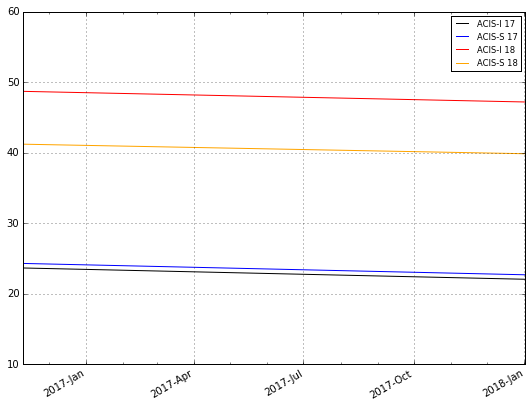

In [7]:
# Plot the cycle 17 and cycle 18 ACIS offsets at -9.5C for the cycle
figure(figsize=(9,7))
for zo in zero_offsets[(zero_offsets['detector'] == 'ACIS-I') | (zero_offsets['detector'] =='ACIS-S')]:
    for t_ccd in [-9.5]:
        rs = []
        dates = ['2016:314', '2017:001', '2017:180', '2018:001']
        for date in dates:
            dy, dz = get_aca_offsets(zo['detector'], zo['chip_id'], zo['chipx'], zo['chipy'], 
                                     date, t_ccd)
            if zo['detector'] == 'ACIS-I':
                dy -= latest_char['dy_acis_i']
                dz -= latest_char['dz_acis_i']
            if zo['detector'] == 'ACIS-S':
                dy -= latest_char['dy_acis_s']
                dz -= latest_char['dz_acis_s']
            r = np.hypot(dy, dz)
            rs.append(r)
        plot_cxctime(DateTime(dates).secs, rs, label="{} {}".format(zo['detector'], zo['cycle_effective']), color=zo['color'])
grid('on')
legend(loc='upper right', fontsize='small')
ylim(10, 60);

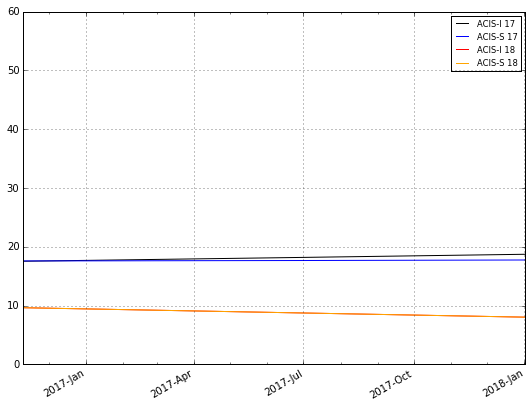

In [8]:
# Plot the cycle 17 and cycle 18 ACIS offsets at -9.5C for the cycle with some re-baselining near the
# cycle 18 values
figure(figsize=(9,7))
for zo in zero_offsets[(zero_offsets['detector'] == 'ACIS-I') | (zero_offsets['detector'] =='ACIS-S')]:
    for t_ccd in [-9.5]:
        rs = []
        dates = ['2016:314', '2017:001', '2017:180', '2018:001']
        for date in dates:
            dy, dz = get_aca_offsets(zo['detector'], zo['chip_id'], zo['chipx'], zo['chipy'], 
                                     date, t_ccd)
            if zo['detector'] == 'ACIS-I':
                dy += 17.59
                dz += 23.17
            if zo['detector'] == 'ACIS-S':
                dy += 3.59
                dz += 23.64
            r = np.hypot(dy, dz)
            rs.append(r)
        plot_cxctime(DateTime(dates).secs, rs, label="{} {}".format(zo['detector'], zo['cycle_effective']), color=zo['color'])
grid('on')
legend(loc='upper right', fontsize='small')
ylim(0, 60);